# GP-Based Power Minimization Simulation

## Model Overview

The full model optimizes the gate widths $W_i$ for a path of $N$ stages. The objective is a power-related capacitance sum scaled by a constant factor $A = \alpha f V_{DD}^2$, while the constraint enforces an Elmore-style timing budget.

The wire lengths $l_i$ describe the interconnect profile between adjacent stages. In the simulation pipeline below, they are treated as fixed experiment inputs rather than optimization variables.

## Why $l_i$ Is Fixed in Simulation

In the legacy formulation, each wire length $l_i$ appears with nonnegative coefficients in both the objective and the timing expression. For fixed widths, increasing $l_i$ always makes the objective larger and never improves the timing constraint. As a result, if $l_i$ is left as a free optimization variable, the optimizer simply pushes every wire length to its smallest allowed value.

That behavior is mathematically valid but physically uninformative, because wire length should represent placement or routing data rather than a free resource that can shrink without cost. For this reason, the experiments below treat $l_i$ as fixed interconnect data and study how different wire profiles change the optimal gate sizing.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from src.baselines import solve_boyd_style_fixed_N
from src.experiments import (
    build_profile_suite,
    choose_common_informative_defaults,
    default_free_length_params,
    default_n_list,
    default_params,
    default_tclk_list,
    run_single_case,
    sweep_free_length_primal_dual_over_Tclk,
    sweep_full_vs_baseline,
    sweep_over_N,
    sweep_over_Tclk,
)
from src.free_length import solve_free_length_primal_and_dual_fixed_N
from src.gp_solver import solve_full_gp_fixed_N
from src.plotting import (
    plot_full_vs_baseline,
    plot_free_length_primal_dual,
    plot_free_length_profile,
    plot_power_vs_N,
    plot_power_vs_Tclk,
    plot_width_profile,
)

plt.rcParams['figure.dpi'] = 120

plot_dir = Path('plots') if Path.cwd().name == 'simulation' else Path('simulation') / 'plots'
plot_dir.mkdir(parents=True, exist_ok=True)

In [2]:
base_params = default_params()
N_default = 6
N_values = default_n_list()

scan_total_length_values = [20.0, 25.0, 30.0, 35.0, 40.0]
scan_Tclk_values = [70.0, 80.0, 90.0, 100.0, 110.0]
scan_CL_values = [10.0, 15.0, 20.0, 30.0]

## Parameter Tuning for an Informative Regime

Before running the main experiments, we scan a small parameter grid to find a setting where the optimizer does more than pin every gate width at the lower bound. The goal is to choose a more informative operating point for visualization and interpretation.

In [3]:
best_candidate, ranked_candidates = choose_common_informative_defaults(
    N=N_default,
    params=base_params,
    total_length_values=scan_total_length_values,
    Tclk_values=scan_Tclk_values,
    CL_values=scan_CL_values,
)

params = dict(best_candidate['result']['params'])
total_length = best_candidate['total_length']
center_tclk = best_candidate['Tclk']
Tclk_values = sorted({
    max(50.0, center_tclk - 20.0),
    max(50.0, center_tclk - 10.0),
    center_tclk,
    center_tclk + 10.0,
    center_tclk + 20.0,
})

print('Selected parameter regime')
print('  N =', N_default)
print('  total_length =', total_length)
print('  Tclk =', params['Tclk'])
print('  CL =', params['CL'])
print('  total_max_width_delta =', round(best_candidate['total_max_width_delta'], 4))
print('  total_active_width_count =', best_candidate['total_active_width_count'])
print()
print('Top candidate settings from the scan')
for candidate in ranked_candidates[:5]:
    print(
        f"  total_length={candidate['total_length']:.1f}, "
        f"Tclk={candidate['Tclk']:.1f}, "
        f"CL={candidate['CL']:.1f}, "
        f"all_feasible={candidate['all_feasible']}, "
        f"total_active_width_count={candidate['total_active_width_count']}, "
        f"total_max_width_delta={candidate['total_max_width_delta']:.4f}, "
        f"total_width_span={candidate['total_width_span']:.4f}"
    )

profiles = build_profile_suite(N_default, total_length)
for name, profile in profiles.items():
    print()
    print(name)
    print(np.round(profile, 2))
    print(f'Total wire length: {profile.sum():.2f}')

Selected parameter regime
  N = 6
  total_length = 25.0
  Tclk = 90.0
  CL = 15.0
  total_max_width_delta = 1.1498
  total_active_width_count = 7

Top candidate settings from the scan
  total_length=25.0, Tclk=90.0, CL=15.0, all_feasible=True, total_active_width_count=7, total_max_width_delta=1.1498, total_width_span=1.1498
  total_length=20.0, Tclk=110.0, CL=30.0, all_feasible=True, total_active_width_count=5, total_max_width_delta=1.9924, total_width_span=1.9925
  total_length=20.0, Tclk=90.0, CL=20.0, all_feasible=True, total_active_width_count=4, total_max_width_delta=1.1140, total_width_span=1.1140
  total_length=20.0, Tclk=80.0, CL=15.0, all_feasible=True, total_active_width_count=3, total_max_width_delta=0.6044, total_width_span=0.6044
  total_length=30.0, Tclk=90.0, CL=10.0, all_feasible=True, total_active_width_count=3, total_max_width_delta=0.4370, total_width_span=0.4370

Uniform
[4.17 4.17 4.17 4.17 4.17 4.17]
Total wire length: 25.00

Back-loaded
[2.08 2.92 3.75 4.58 5.42 

## Single-Case Sanity Check

We first solve one representative wire-aware case to confirm that the model returns a feasible timing ratio and a reasonable width allocation.

In [4]:
single_case = run_single_case(
    N=N_default,
    params=params,
    total_length=total_length,
    profile_name='Back-loaded',
)

print('Status:', single_case['status'])
print('Objective:', single_case['obj'])
print('Timing ratio:', single_case['timing_ratio'])
print('Optimal widths:', np.round(single_case['W'], 4))
print('Wire profile:', np.round(single_case['l_profile'], 4))

Status: optimal
Objective: 1.441418412981353
Timing ratio: 1.0000004937247227
Optimal widths: [0.9673 0.5243 0.5    0.5084 0.6338 1.4383]
Wire profile: [2.0833 2.9167 3.75   4.5833 5.4167 6.25  ]


The single-case solve should show a timing ratio at or below 1 and, under the tuned parameter regime, at least some widths above the lower bound. Later stages often become wider when the profile is back-loaded because the optimizer is compensating for heavier downstream loading and larger wire delay contributions.

## Experiment 1: Power vs Number of Stages

This sweep compares three wire profiles while varying the number of stages. The total wire length is kept fixed so the comparison reflects how the same path is partitioned across more or fewer stages. If a point is physically infeasible under the current timing budget, it is recorded as a missing value instead of stopping the notebook.

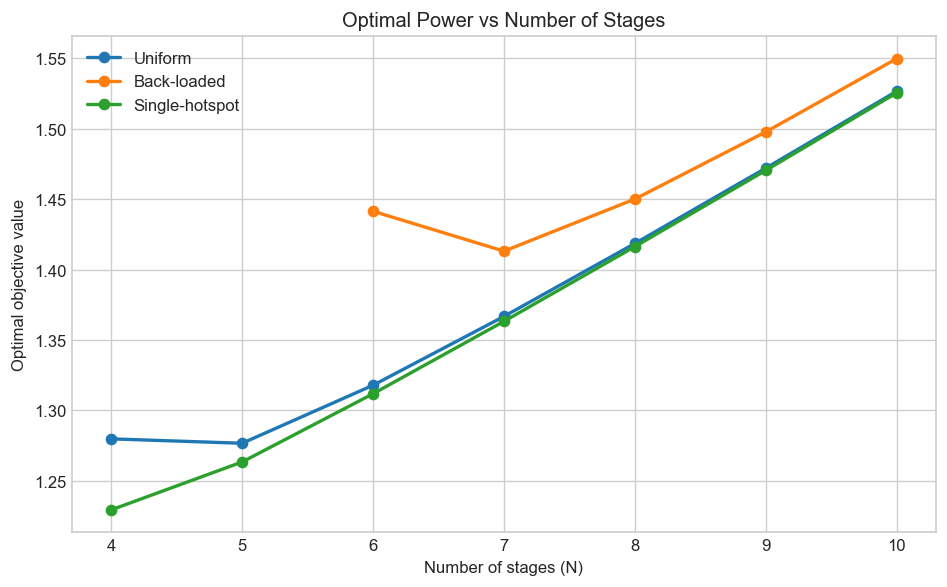

In [5]:
results_vs_N = sweep_over_N(
    N_list=N_values,
    params=params,
    total_length=total_length,
)

fig, ax = plot_power_vs_N(results_vs_N)
fig.savefig(plot_dir / 'power_vs_N.png', bbox_inches='tight')
plt.show()

This figure shows how the optimal objective changes as the path is repartitioned. Differences across the curves indicate that the spatial distribution of wire length matters, not just the total amount of wire. Missing points indicate infeasible settings under the current timing budget.

## Experiment 2: Power vs Timing Budget

Next, we fix the stage count and sweep the clock period. A tighter timing budget should generally force more aggressive sizing and therefore a higher objective value. If the model becomes infeasible for a very tight budget, the corresponding point is left blank.

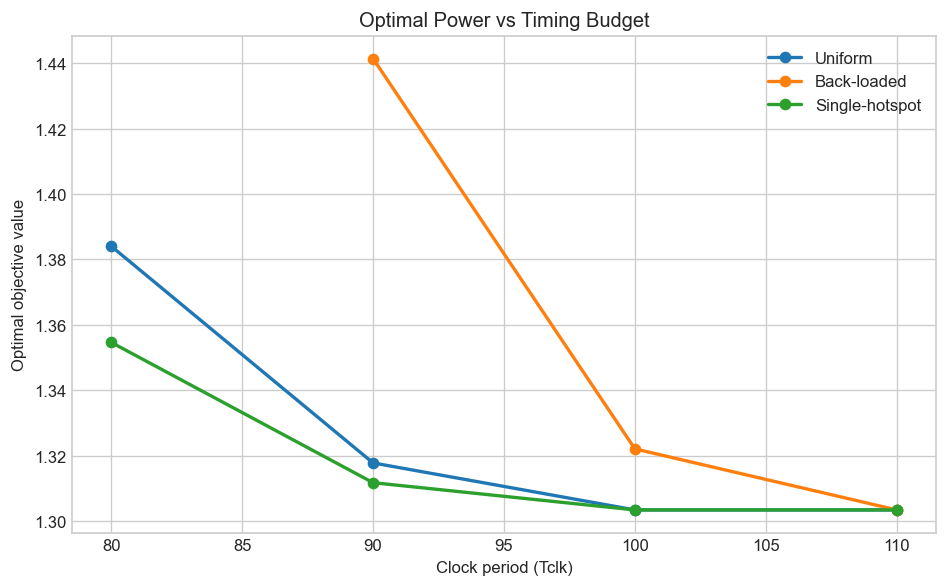

In [6]:
results_vs_Tclk = sweep_over_Tclk(
    N=N_default,
    Tclk_list=Tclk_values,
    params=params,
    total_length=total_length,
)

fig, ax = plot_power_vs_Tclk(results_vs_Tclk)
fig.savefig(plot_dir / 'power_vs_Tclk.png', bbox_inches='tight')
plt.show()

The slope of each curve reflects how sensitive the model is to timing pressure. If one wire profile sits consistently above another, that profile is more expensive to satisfy under the same timing target.

## Experiment 3: Optimal Width Allocation

This experiment compares the stage-by-stage width allocation under the three fixed wire profiles for one representative timing budget.

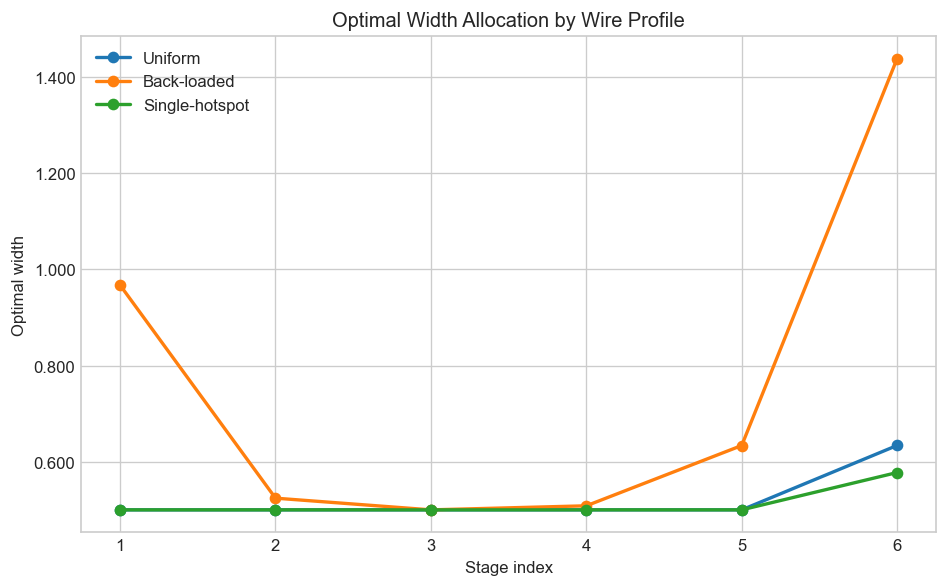

In [7]:
width_results = {}
for profile_name in ['Uniform', 'Back-loaded', 'Single-hotspot']:
    width_results[profile_name] = run_single_case(
        N=N_default,
        params=params,
        total_length=total_length,
        profile_name=profile_name,
    )

fig, ax = plot_width_profile(width_results, title='Optimal Width Allocation by Wire Profile')
fig.savefig(plot_dir / 'width_allocation_profiles.png', bbox_inches='tight')
plt.show()

When one profile places more wire length near a particular stage or near the output end of the path, the optimizer may enlarge nearby gates to compensate. This gives a direct visual explanation for why wire-aware modeling can produce different design recommendations than a gate-only baseline.

## Experiment 4: Comparison with a Boyd-Style Baseline

The baseline below removes wire resistance and wire-capacitance coupling terms. It is not intended to reproduce Boyd et al. exactly; instead, it provides a controlled ablation that isolates the effect of wire-aware modeling.

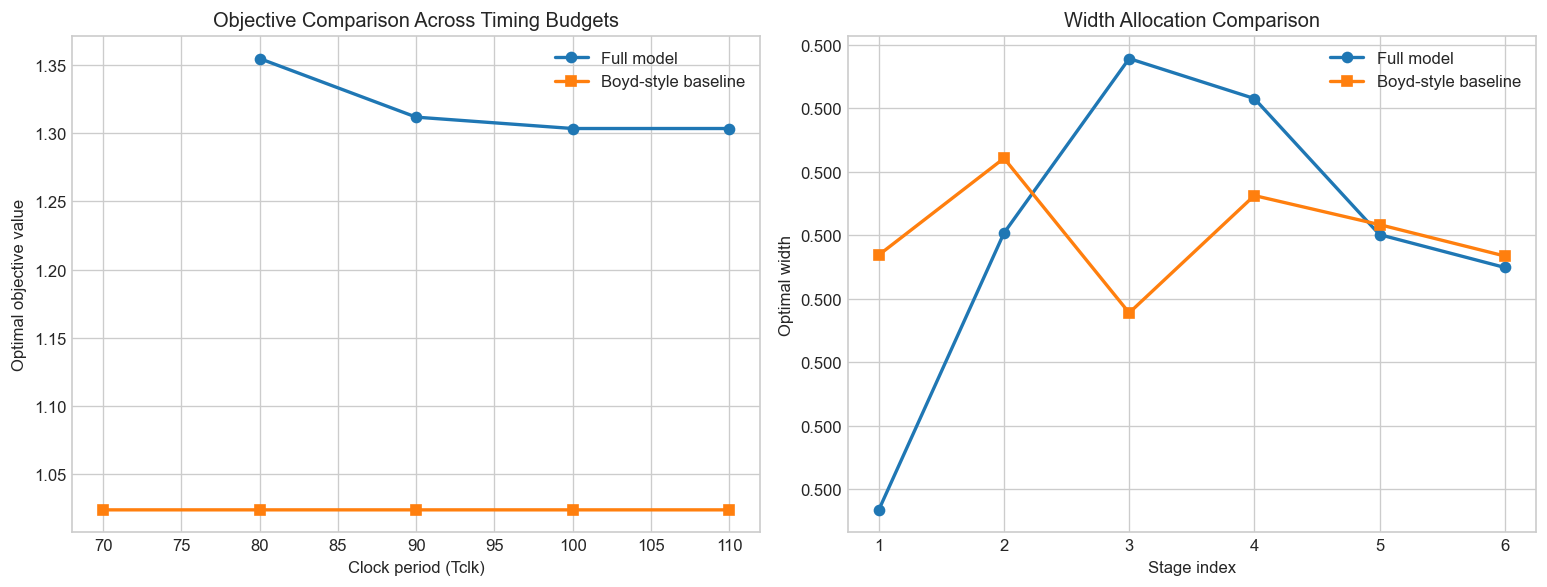

In [8]:
comparison_results = sweep_full_vs_baseline(
    N=N_default,
    Tclk_list=Tclk_values,
    params=params,
    total_length=total_length,
    profile_name='Single-hotspot',
)

feasible_cases = [
    item for item in comparison_results
    if item['full']['W'] is not None and item['baseline']['W'] is not None
]
if not feasible_cases:
    raise RuntimeError('No feasible comparison case was found for width plotting.')

representative_case = feasible_cases[len(feasible_cases) // 2]

fig, axes = plot_full_vs_baseline(
    comparison_results,
    representative_case['full'],
    representative_case['baseline'],
)
fig.savefig(plot_dir / 'full_vs_baseline.png', bbox_inches='tight')
plt.show()

## Extension: Free-Length Formulation and Dual

In the main experiments above, we fixed the wire lengths $l_i$ to obtain more interpretable wire-aware simulations. In this extension, we briefly return to the unrestricted formulation where both $W_i$ and $l_i$ are optimized. This lets us examine the behavior of the free-length primal problem and compare it directly with its dual.

In [9]:
free_params = default_free_length_params(params)
free_params['Tclk'] = params['Tclk']
free_params['CL'] = params['CL']

free_length_comparison = solve_free_length_primal_and_dual_fixed_N(
    N_default,
    free_params,
)

free_primal = free_length_comparison['primal']
free_dual = free_length_comparison['dual']

print('Free-length primal status:', free_primal['status'])
print('Free-length dual status:', free_dual['status'])
print('Primal objective:', free_primal['obj'])
print('Dual-implied objective:', free_dual['dual_obj'])
print('Primal log objective:', free_primal['log_obj_unscaled'])
print('Dual log objective:', free_dual['dual_log_obj_unscaled'])
print('Log-domain duality gap:', free_length_comparison['log_gap'])
print('Optimal widths:', np.round(free_primal['W'], 4))
print('Optimal free wire lengths:', np.round(free_primal['L'], 4))

Free-length primal status: optimal
Free-length dual status: optimal
Primal objective: 1.05761632792395
Dual-implied objective: 1.0576159113311654
Primal log objective: 3.0719526095249106
Dual log objective: 3.0719522156269954
Log-domain duality gap: 3.9389791517407957e-07
Optimal widths: [0.5 0.5 0.5 0.5 0.5 0.5]
Optimal free wire lengths: [0.5 0.5 0.5 0.5 0.5 0.5]


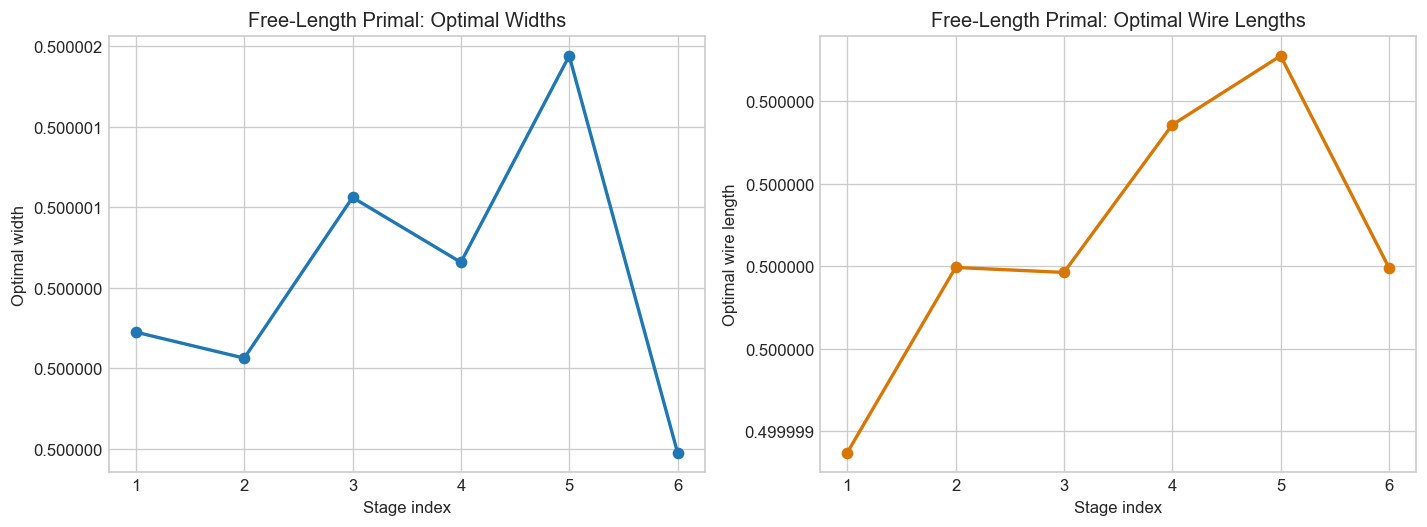

In [10]:
fig, axes = plot_free_length_profile(free_primal)
fig.savefig(plot_dir / 'free_length_profiles.png', bbox_inches='tight')
plt.show()

If the optimized wire lengths collapse to the lower bound $\epsilon$, that confirms the degeneracy issue discussed earlier. In other words, the unrestricted problem is mathematically solvable, but its wire-length solution may be physically uninformative, which is why the main simulation fixes $l_i$ as an input profile.

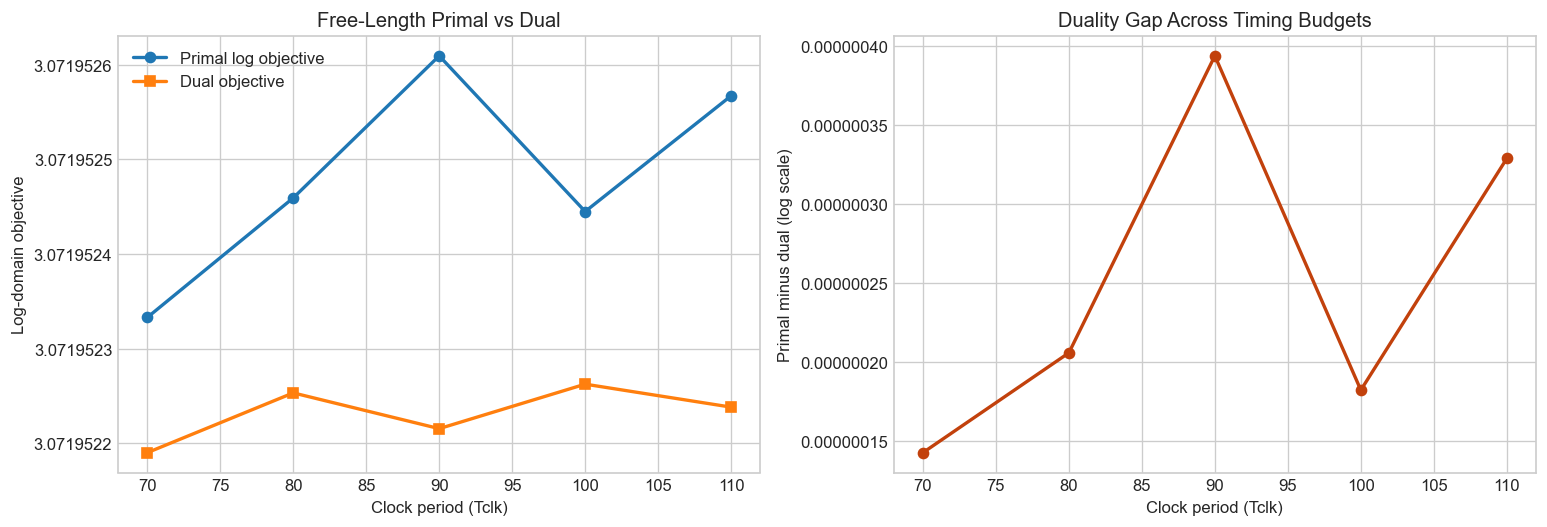

Tclk=70.0, primal_obj=1.057616, dual_obj=1.057616, log_gap=1.428e-07
Tclk=80.0, primal_obj=1.057616, dual_obj=1.057616, log_gap=2.060e-07
Tclk=90.0, primal_obj=1.057616, dual_obj=1.057616, log_gap=3.939e-07
Tclk=100.0, primal_obj=1.057616, dual_obj=1.057616, log_gap=1.824e-07
Tclk=110.0, primal_obj=1.057616, dual_obj=1.057616, log_gap=3.290e-07


In [11]:
free_sweep_results = sweep_free_length_primal_dual_over_Tclk(
    N=N_default,
    Tclk_list=Tclk_values,
    params=free_params,
)

fig, axes = plot_free_length_primal_dual(free_sweep_results)
fig.savefig(plot_dir / 'free_length_primal_dual.png', bbox_inches='tight')
plt.show()

for item in free_sweep_results:
    print(
        f"Tclk={item['Tclk']:.1f}, "
        f"primal_obj={item['primal']['obj']:.6f}, "
        f"dual_obj={item['dual']['dual_obj']:.6f}, "
        f"log_gap={item['log_gap']:.3e}"
    )

This comparison is the numerical validation piece for the unrestricted formulation. A very small gap between the free-length primal and dual objectives indicates that the dual is consistent with the primal problem being solved in this section.